In [1]:
%matplotlib inline
import pathlib
dir_path = pathlib.Path.home()/pathlib.Path('Documents/gamma_control_log/answers.csv')
assert dir_path.exists()

import pandas

In [2]:
df = pandas.read_csv(dir_path)
df.head()

,Unnamed: 0,session_type,event_name,???,response,key,mouse_X,mouse_Y,error_code,reaction_time,participant_id,block,session_type_name,outcome
0,5,8,response,NaN,Left,Pressed,800.0,-64.0,C,8111,4221,1,deviant,Miss
1,11,7,response,NaN,Left,Pressed,800.0,-64.0,C,8628,4221,1,deviant,Miss
2,17,3,response,NaN,Left,Pressed,800.0,-64.0,C,8228,4221,1,standard,Correct reject
3,23,5,response,NaN,Left,Pressed,800.0,-64.0,C,8670,4221,1,standard,Correct reject
4,29,6,response,NaN,Right,Pressed,800.0,-64.0,C,8292,4221,1,deviant,Hit


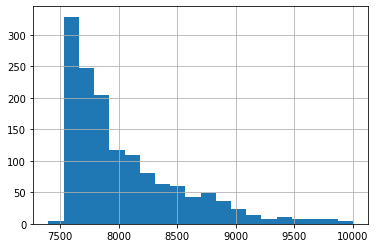

In [3]:
df.reaction_time.hist(bins=20, range=(7400, 10000))

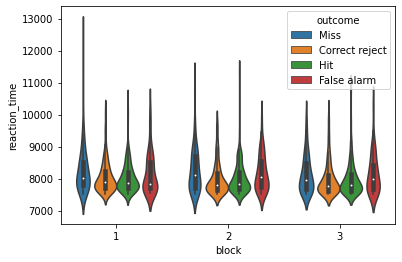

In [4]:
import seaborn
seaborn.violinplot(
    x='block', y='reaction_time', hue='outcome', data=df,

)

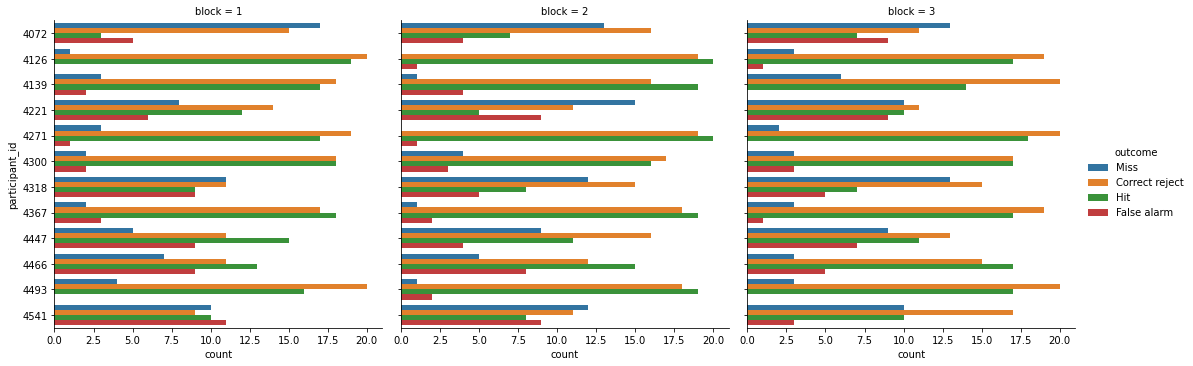

In [5]:
seaborn.catplot(y='participant_id', hue='outcome', col='block', kind='count', data=df)

In [6]:
def rate_per_pid(pid: int, df):
    pdf = df[df.participant_id==pid]
    total = len(pdf)
    cond_dict = {cond:len(pdf[pdf.outcome==cond])/60 for cond in set(df.outcome)}
    return cond_dict

correct_dict = dict()
cond_dict = dict()
for pid in set(df.participant_id):
    cond_dict[pid] = rate_per_pid(pid, df)
    correct_dict[pid] = (cond_dict[pid]['Hit'] + cond_dict[pid]['Correct reject'])/2.
correct_dict

{4072: 0.49166666666666664,
 4139: 0.8666666666666667,
 4300: 0.8583333333333334,
 4493: 0.9166666666666667,
 4271: 0.9416666666666667,
 4367: 0.9,
 4466: 0.6916666666666667,
 4221: 0.525,
 4318: 0.5416666666666667,
 4541: 0.5416666666666667,
 4126: 0.95,
 4447: 0.6416666666666666}

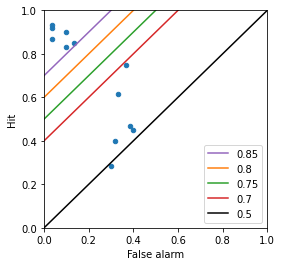

In [29]:
crdf = pandas.DataFrame.from_dict(cond_dict, orient='index')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
ax = crdf.plot.scatter(x='False alarm', y='Hit', xlim=(0, 1), ylim=(0, 1), ax=ax)

ax.plot([0, 0.3], [0.7, 1], color='C4', label=0.85)
ax.plot([0, 0.4], [0.6, 1], color='C1', label=0.8)
ax.plot([0, 0.5], [0.5, 1], color='C2', label=0.75)
ax.plot([0, 0.6], [0.4, 1], color='C3', label=0.7)
ax.plot([1., 0.], [1., 0.], color='k', label=0.5)
plt.legend()


In [8]:
for key, item in correct_dict.items():
    if item > 0.8:
        print(key)

4139
4300
4493
4271
4367
4126


In [9]:
crdf = pandas.read_csv('correct_rate.csv')
crdf

,Unnamed: 0,4072,4139,4300,4493,4271,4367,4466,4126,4221,4318,4447
0,Hit,17,50,51,52,55,54,45,56,27,24,37
1,Miss,43,10,9,8,5,6,15,4,33,36,23
2,Correct reject,42,54,52,58,58,54,38,58,36,41,40
3,False alarm,18,6,8,2,2,6,22,2,24,19,20
